BASE_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз
SHP_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\shp_dbf
OUT_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result
sed 101 EPSG:32649
lyth 15 EPSG:32649
paleo 6 EPSG:32649
struct 19 EPSG:32649
magm 151 EPSG:32649
tect_nw 4 EPSG:32649
tect_ne 2 EPSG:32649

Дополнительные слои для pseudo-labels:
 - result.shp 1332 {'Point'}
 - геохимические ореолы.shp 14 {'LineString'}
 - геохимическое_опробование.shp 76 {'Point'}
 - привнос урана.shp 23 {'LineString'}
Объектов-кандидатов для положительного класса: 1445
Ячеек в области прогноза: 15684

Распределение pseudo-labels:
label
1    3769
0    1998
Name: count, dtype: int64

Источники labels:
label_source
positive_near_object        3769
negative_far_from_object    1998
Name: count, dtype: int64
Число spatial groups: 246

Признаки модели:
 - near_lyth
 - near_paleo
 - near_struct
 - near_magm
 - near_tect_nw
 - near_tect_ne
 - lyth_pr_n
 - paleo_pr_n
 - struct

,fold,n_train,n_valid,positive_valid,roc_auc,average_precision
0,1,4613,1154,874,0.998790,0.999610
1,2,4613,1154,632,0.998827,0.999008
2,3,4614,1153,768,0.989110,0.994764
3,4,4614,1153,682,0.998004,0.998608
4,5,4614,1153,813,0.995105,0.997871



Средние метрики:


,mean
roc_auc,0.995967
average_precision,0.997972



OOF ROC-AUC: 0.9955608301323344
OOF Average Precision: 0.9976359612203137

RF feature importance:


,feature,importance
10,tect_nw_pr_n,0.128016
4,near_tect_nw,0.124815
21,cy,0.114793
18,full_coincidence,0.069430
15,paleo_lyth,0.065254
14,struct_tect,0.063863
13,tect_mean,0.055319
8,struct_pr_n,0.051364
2,near_struct,0.051276
20,cx,0.044294



Permutation importance:


,feature,perm_importance_mean,perm_importance_std
21,cy,2.063198e-04,8.651539e-06
10,tect_nw_pr_n,8.605071e-05,6.843885e-06
4,near_tect_nw,5.958622e-05,5.111840e-06
13,tect_mean,3.889273e-05,2.129620e-05
18,full_coincidence,2.341244e-05,3.309772e-06
20,cx,6.604019e-06,1.270323e-06
8,struct_pr_n,5.798411e-06,5.978824e-07
2,near_struct,3.862634e-06,1.894783e-07
14,struct_tect,2.933056e-06,7.914493e-07
15,paleo_lyth,2.861096e-06,7.769208e-07


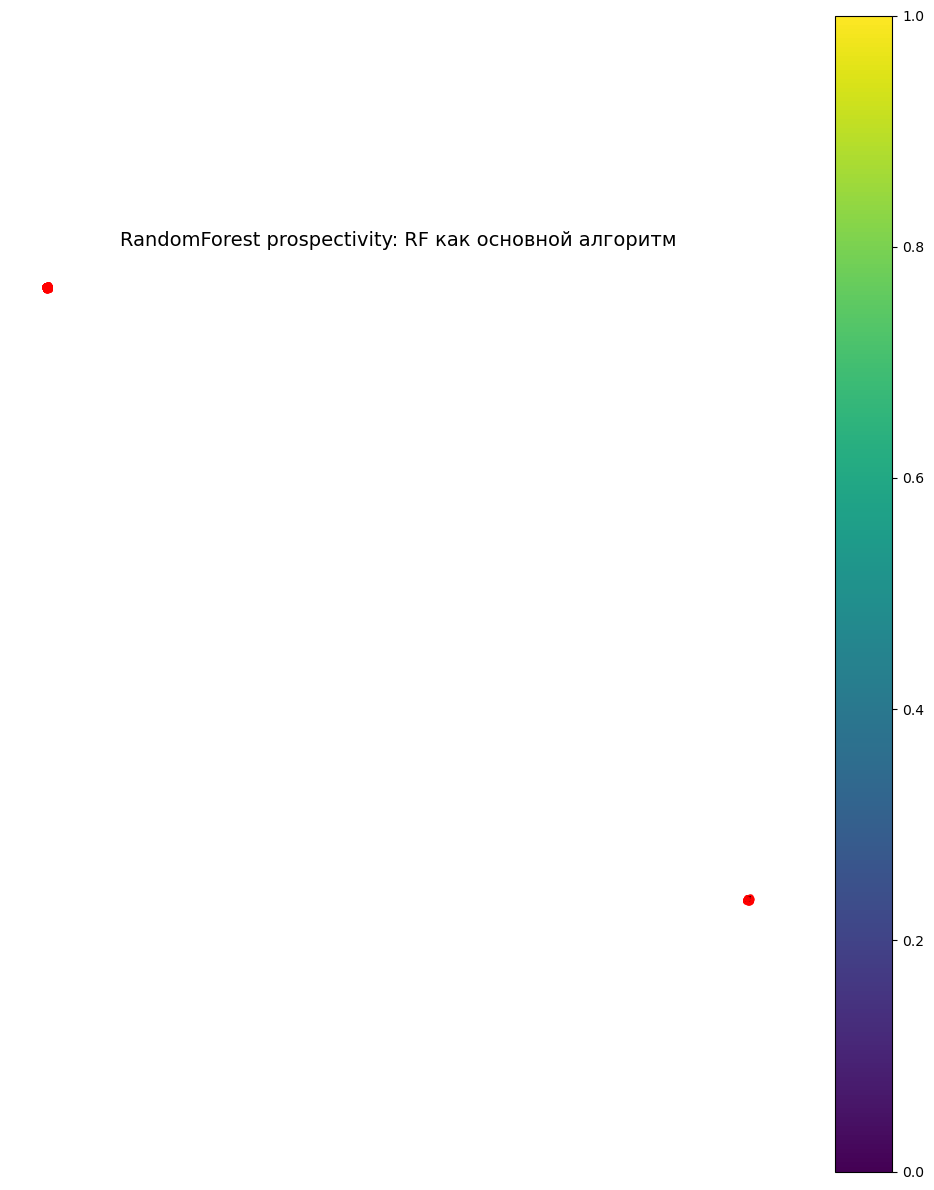

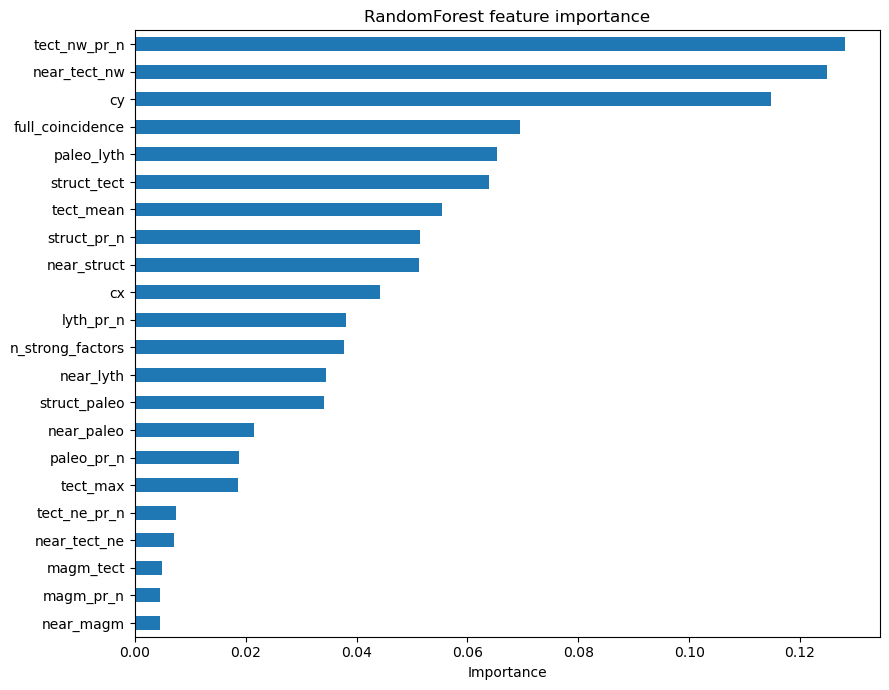


ГОТОВО
GPKG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result\forecast_rf_main_groupkfold.gpkg
CSV: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result\grid_rf_main_groupkfold.csv
PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result\forecast_rf_main_groupkfold.png
IMPORTANCE PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result\feature_importance_rf.png
METRICS JSON: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\rf_main_groupkfold_result\metrics_rf_main_groupkfold.json

Статистика результата:


,prospectivity,prognoz,rf_score,rf_score_sm
count,15684.000000,15684.000000,15684.000000,15684.000000
mean,0.763436,0.236564,0.763374,0.763436
std,0.349187,0.349187,0.354258,0.349187
min,0.000000,0.000000,0.000000,0.000000
25%,0.663910,0.002929,0.670802,0.663910
50%,0.966770,0.033230,0.970914,0.966770
75%,0.997071,0.336090,0.997822,0.997071
max,1.000000,1.000000,1.000000,1.000000



Топ-10 наиболее перспективных ячеек:


,cell_id,prospectivity,prognoz,rf_score_sm,n_strong_factors,label,label_source
2014,2014,1.0,0.0,1.0,4,NaN,unlabeled
14175,14175,1.0,0.0,1.0,2,1.0,positive_near_object
14168,14168,1.0,0.0,1.0,2,1.0,positive_near_object
14169,14169,1.0,0.0,1.0,2,1.0,positive_near_object
14170,14170,1.0,0.0,1.0,2,1.0,positive_near_object
14171,14171,1.0,0.0,1.0,3,NaN,unlabeled
14172,14172,1.0,0.0,1.0,3,NaN,unlabeled
14173,14173,1.0,0.0,1.0,3,1.0,positive_near_object
14174,14174,1.0,0.0,1.0,3,1.0,positive_near_object
928,928,1.0,0.0,1.0,1,NaN,unlabeled


In [3]:
# ============================================================
# БЛОК "ПРОГНОЗ": RandomForest как основной алгоритм
# - без geo_score_sm в признаках
# - pseudo-labels по точкам / аномалиям
# - пространственный GroupKFold
# - итог: prospectivity, prognoz = 1 - prospectivity
# ============================================================

import os
import re
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")


# ============================================================
# 0. НАСТРОЙКИ
# ============================================================

RANDOM_STATE = 42
CELL_SIZE = 500

N_SPLITS = 5

RF_PARAMS = dict(
    n_estimators=700,
    max_depth=14,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Радиусы для pseudo-labels
POS_RADIUS_M = 750
NEG_SAFE_RADIUS_M = 3500

# Доли наиболее перспективных / неперспективных ячеек для pseudo-labels,
# если точек мало или они не найдены
PSEUDO_POS_QUANTILE = 0.92
PSEUDO_NEG_QUANTILE = 0.25

# Сглаживание результата
SMOOTH_RADIUS_CELLS = 1

# Выходные файлы
OUT_DIR_NAME = "rf_main_groupkfold_result"


# ============================================================
# 1. ПОИСК / РАСПАКОВКА ДАННЫХ
# ============================================================

def find_or_unpack_data():
    candidates = [
        Path.cwd(),
        Path("/mnt/data"),
        Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"),
    ]

    for base in candidates:
        if (base / "shp_dbf" / "svita_new.shp").exists():
            return base

    zip_candidates = [
        Path.cwd() / "Прогноз.zip",
        Path("/mnt/data/Прогноз.zip"),
    ]

    for zpath in zip_candidates:
        if zpath.exists():
            out = zpath.parent / "prognoz_unpacked"
            out.mkdir(exist_ok=True)
            with zipfile.ZipFile(zpath, "r") as z:
                z.extractall(out)
            if (out / "shp_dbf" / "svita_new.shp").exists():
                return out

    raise FileNotFoundError(
        "Не найден каталог shp_dbf и не найден архив Прогноз.zip. "
        "Положи Прогноз.zip рядом с ноутбуком или укажи путь вручную."
    )


BASE_DIR = find_or_unpack_data()
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("SHP_DIR:", SHP_DIR)
print("OUT_DIR:", OUT_DIR)


# ============================================================
# 2. СЛУЖЕБНЫЕ ФУНКЦИИ
# ============================================================

def read_vector(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    last_err = None
    for enc in ["utf-8", "cp1251", "latin1"]:
        try:
            gdf = gpd.read_file(path, encoding=enc)
            gdf = gdf[~gdf.geometry.isna()].copy()
            gdf = gdf[gdf.geometry.is_valid].copy()
            return gdf
        except Exception as e:
            last_err = e

    raise last_err


def ensure_projected(gdf, fallback_epsg=32649):
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=fallback_epsg)
    if not gdf.crs.is_projected:
        gdf = gdf.to_crs(epsg=fallback_epsg)
    return gdf


def normalize_01(x):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)
    out = np.zeros_like(x, dtype=float)

    if good.sum() == 0:
        return out

    mn = np.nanmin(x[good])
    mx = np.nanmax(x[good])

    if np.isclose(mx, mn):
        out[good] = 0.5
    else:
        out[good] = (x[good] - mn) / (mx - mn)

    return out


def robust_normalize_01(x, q_low=0.02, q_high=0.98):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)
    out = np.zeros_like(x, dtype=float)

    if good.sum() == 0:
        return out

    lo = np.nanquantile(x[good], q_low)
    hi = np.nanquantile(x[good], q_high)

    if np.isclose(lo, hi):
        return normalize_01(x)

    clipped = np.clip(x, lo, hi)
    out[good] = (clipped[good] - lo) / (hi - lo)
    return out


def inv_distance_score(distance_m, q=0.95):
    """
    Близость к фактору:
    1 — близко,
    0 — далеко.
    """
    d = np.asarray(distance_m, dtype=float)
    good = np.isfinite(d)

    out = np.zeros_like(d, dtype=float)
    if good.sum() == 0:
        return out

    scale = np.nanquantile(d[good], q)
    if scale <= 0 or not np.isfinite(scale):
        scale = np.nanmax(d[good])

    if scale <= 0 or not np.isfinite(scale):
        return out

    out[good] = 1 - np.clip(d[good] / scale, 0, 1)
    return out


def centroid_distance_to_layer(grid, layer):
    if layer.empty:
        return np.full(len(grid), np.nan)

    geom = unary_union(layer.geometry)
    cent = grid.geometry.centroid
    return cent.distance(geom).values


def smooth_grid_values(grid, value_col, radius_cells=1):
    """
    Простое пространственное сглаживание через соседние ячейки.
    Исправленная версия для itertuples().
    """
    if radius_cells <= 0:
        return grid[value_col].values

    df = grid[["ix", "iy", value_col]].copy()

    lookup = {}
    for row in df.itertuples(index=False):
        lookup[(int(row.ix), int(row.iy))] = float(getattr(row, value_col))

    smoothed = []
    for row in df.itertuples(index=False):
        vals = []
        ix = int(row.ix)
        iy = int(row.iy)

        for dx in range(-radius_cells, radius_cells + 1):
            for dy in range(-radius_cells, radius_cells + 1):
                v = lookup.get((ix + dx, iy + dy))
                if v is not None and np.isfinite(v):
                    vals.append(v)

        smoothed.append(np.mean(vals) if vals else float(getattr(row, value_col)))

    return np.asarray(smoothed)


def safe_save_gpkg(gdf, path, layer="forecast"):
    path = Path(path)
    if path.exists():
        path.unlink()
    gdf.to_file(path, layer=layer, driver="GPKG")


# ============================================================
# 3. ЗАГРУЗКА СЛОЁВ
# ============================================================

layers = {
    "sed": SHP_DIR / "svita_new.shp",              # маска: свиты
    "lyth": SHP_DIR / "fasii.shp",                 # литолого-фациальный
    "paleo": SHP_DIR / "gr_dol_vp_poly.shp",       # палеодолины и впадины
    "struct": SHP_DIR / "kory.shp",                # коры выветривания
    "magm": SHP_DIR / "dayki_buf.shp",             # дайки / буфер даек
    "tect_nw": SHP_DIR / "glub_raz_nw.shp",        # глубинные разломы СЗ
    "tect_ne": SHP_DIR / "glub_r_nw.shp",          # региональные / прочие разломы
}

data = {}
for name, path in layers.items():
    data[name] = ensure_projected(read_vector(path))
    print(name, len(data[name]), data[name].crs)

target_crs = data["sed"].crs
for name in data:
    data[name] = data[name].to_crs(target_crs)


# ============================================================
# 4. ПОИСК ТОЧЕК / АНОМАЛИЙ ДЛЯ PSEUDO-LABELS
# ============================================================

def discover_point_or_anomaly_layers(shp_dir):
    """
    Ищем дополнительные shp, которые не являются основными факторами.
    Они могут быть точками минерализации, геохимическими аномалиями и т.п.
    """
    known = {p.name.lower() for p in layers.values()}
    found = []

    for shp in Path(shp_dir).glob("*.shp"):
        if shp.name.lower() in known:
            continue

        try:
            g = ensure_projected(read_vector(shp)).to_crs(target_crs)
            if len(g) == 0:
                continue

            geom_types = set(g.geometry.geom_type.astype(str))
            found.append((shp, g, geom_types))
        except Exception:
            pass

    return found


extra_layers = discover_point_or_anomaly_layers(SHP_DIR)

print("\nДополнительные слои для pseudo-labels:")
for shp, g, geom_types in extra_layers:
    print(" -", shp.name, len(g), geom_types)

positive_layers = []
for shp, g, geom_types in extra_layers:
    positive_layers.append(g)

if positive_layers:
    pos_gdf = gpd.GeoDataFrame(
        pd.concat(positive_layers, ignore_index=True),
        geometry="geometry",
        crs=target_crs
    )
else:
    pos_gdf = gpd.GeoDataFrame(geometry=[], crs=target_crs)

print("Объектов-кандидатов для положительного класса:", len(pos_gdf))


# ============================================================
# 5. СОЗДАНИЕ СЕТКИ 500 х 500 М
# ============================================================

mask_geom = unary_union(data["sed"].geometry)
minx, miny, maxx, maxy = data["sed"].total_bounds

xs = np.arange(minx, maxx + CELL_SIZE, CELL_SIZE)
ys = np.arange(miny, maxy + CELL_SIZE, CELL_SIZE)

cells = []
ixs = []
iys = []

for ix, x in enumerate(xs[:-1]):
    for iy, y in enumerate(ys[:-1]):
        geom = box(x, y, x + CELL_SIZE, y + CELL_SIZE)
        if geom.intersects(mask_geom):
            cells.append(geom)
            ixs.append(ix)
            iys.append(iy)

grid = gpd.GeoDataFrame(
    {"ix": ixs, "iy": iys},
    geometry=cells,
    crs=target_crs
)

grid["cell_id"] = np.arange(len(grid))
grid["cx"] = grid.geometry.centroid.x
grid["cy"] = grid.geometry.centroid.y

print("Ячеек в области прогноза:", len(grid))


# ============================================================
# 6. РАСЧЁТ ML-ПРИЗНАКОВ
# ============================================================

# Расстояния
for name in ["lyth", "paleo", "struct", "magm", "tect_nw", "tect_ne"]:
    grid[f"dist_{name}"] = centroid_distance_to_layer(grid, data[name])
    grid[f"near_{name}"] = inv_distance_score(grid[f"dist_{name}"])

# Трансформации расстояний, аналогичные логике методички
grid["lyth_pr"] = np.cbrt(grid["dist_lyth"])
grid["paleo_pr"] = np.cbrt(grid["dist_paleo"])
grid["struct_pr"] = np.sqrt(grid["dist_struct"])
grid["magm_pr"] = np.sqrt(grid["dist_magm"])
grid["tect_nw_pr"] = np.cbrt(grid["dist_tect_nw"])
grid["tect_ne_pr"] = np.cbrt(grid["dist_tect_ne"])

for col in ["lyth_pr", "paleo_pr", "struct_pr", "magm_pr", "tect_nw_pr", "tect_ne_pr"]:
    grid[f"{col}_n"] = robust_normalize_01(grid[col])

# Близость: чем больше, тем перспективнее
near_cols = [
    "near_lyth",
    "near_paleo",
    "near_struct",
    "near_magm",
    "near_tect_nw",
    "near_tect_ne",
]

# Комбинации факторов — это уже ML-признаки, а не итоговая формула
grid["tect_max"] = grid[["near_tect_nw", "near_tect_ne"]].max(axis=1)
grid["tect_mean"] = grid[["near_tect_nw", "near_tect_ne"]].mean(axis=1)

grid["struct_tect"] = grid["near_struct"] * grid["tect_max"]
grid["paleo_lyth"] = grid["near_paleo"] * grid["near_lyth"]
grid["magm_tect"] = grid["near_magm"] * grid["tect_max"]
grid["struct_paleo"] = grid["near_struct"] * grid["near_paleo"]
grid["full_coincidence"] = (
    grid["near_lyth"]
    * grid["near_paleo"]
    * grid["near_struct"]
    * grid["tect_max"]
)

# Число сильных факторов в ячейке
strong_matrix = []
for col in near_cols:
    strong_matrix.append((grid[col] >= grid[col].quantile(0.70)).astype(int))
grid["n_strong_factors"] = np.vstack(strong_matrix).sum(axis=0)

# ВНИМАНИЕ:
# geo_score_sm НЕ создаём и НЕ добавляем в признаки.
# RandomForest будет главным алгоритмом.


# ============================================================
# 7. PSEUDO-LABELS
# ============================================================

grid["label"] = np.nan
grid["label_source"] = "unlabeled"

if len(pos_gdf) > 0:
    pos_geom = unary_union(pos_gdf.geometry)

    # Расстояние до известных точек / аномалий
    grid["dist_positive"] = grid.geometry.centroid.distance(pos_geom)

    # Положительный класс: близко к точкам / аномалиям
    pos_mask = grid["dist_positive"] <= POS_RADIUS_M

    # Отрицательный класс: далеко от точек / аномалий
    # и при этом без выраженного совпадения сильных факторов
    neg_mask = (
        (grid["dist_positive"] >= NEG_SAFE_RADIUS_M)
        & (grid["n_strong_factors"] <= 2)
        & (grid["full_coincidence"] <= grid["full_coincidence"].quantile(0.60))
    )

    grid.loc[pos_mask, "label"] = 1
    grid.loc[pos_mask, "label_source"] = "positive_near_object"

    grid.loc[neg_mask, "label"] = 0
    grid.loc[neg_mask, "label_source"] = "negative_far_from_object"

else:
    print(
        "Предупреждение: дополнительные точки / аномалии не найдены. "
        "Будут использованы только pseudo-labels по сочетанию факторов."
    )

# Если положительных мало — добавляем верхний квантиль по совпадению факторов
min_pos = max(30, int(0.01 * len(grid)))
current_pos = int((grid["label"] == 1).sum())

if current_pos < min_pos:
    pseudo_pos_mask = (
        grid["label"].isna()
        & (grid["full_coincidence"] >= grid["full_coincidence"].quantile(PSEUDO_POS_QUANTILE))
        & (grid["n_strong_factors"] >= 4)
    )
    grid.loc[pseudo_pos_mask, "label"] = 1
    grid.loc[pseudo_pos_mask, "label_source"] = "pseudo_positive_factor_coincidence"

# Если отрицательных мало — добавляем нижний квантиль
min_neg = max(100, int(0.05 * len(grid)))
current_neg = int((grid["label"] == 0).sum())

if current_neg < min_neg:
    pseudo_neg_mask = (
        grid["label"].isna()
        & (grid["full_coincidence"] <= grid["full_coincidence"].quantile(PSEUDO_NEG_QUANTILE))
        & (grid["n_strong_factors"] <= 2)
    )
    grid.loc[pseudo_neg_mask, "label"] = 0
    grid.loc[pseudo_neg_mask, "label_source"] = "pseudo_negative_low_factors"

train_grid = grid.dropna(subset=["label"]).copy()
train_grid["label"] = train_grid["label"].astype(int)

print("\nРаспределение pseudo-labels:")
print(train_grid["label"].value_counts())
print("\nИсточники labels:")
print(train_grid["label_source"].value_counts())


# ============================================================
# 8. ПРОСТРАНСТВЕННЫЕ ГРУППЫ ДЛЯ GroupKFold
# ============================================================

# Группы крупнее ячейки, чтобы train/test были пространственно разделены
GROUP_SIZE_M = CELL_SIZE * 8

grid["gx"] = np.floor((grid["cx"] - grid["cx"].min()) / GROUP_SIZE_M).astype(int)
grid["gy"] = np.floor((grid["cy"] - grid["cy"].min()) / GROUP_SIZE_M).astype(int)
grid["spatial_group"] = grid["gx"].astype(str) + "_" + grid["gy"].astype(str)

train_grid["gx"] = np.floor((train_grid["cx"] - grid["cx"].min()) / GROUP_SIZE_M).astype(int)
train_grid["gy"] = np.floor((train_grid["cy"] - grid["cy"].min()) / GROUP_SIZE_M).astype(int)
train_grid["spatial_group"] = train_grid["gx"].astype(str) + "_" + train_grid["gy"].astype(str)

print("Число spatial groups:", train_grid["spatial_group"].nunique())


# ============================================================
# 9. СПИСОК ПРИЗНАКОВ
# ============================================================

feature_cols = [
    # Близости
    "near_lyth",
    "near_paleo",
    "near_struct",
    "near_magm",
    "near_tect_nw",
    "near_tect_ne",

    # Трансформированные расстояния
    "lyth_pr_n",
    "paleo_pr_n",
    "struct_pr_n",
    "magm_pr_n",
    "tect_nw_pr_n",
    "tect_ne_pr_n",

    # Взаимодействия
    "tect_max",
    "tect_mean",
    "struct_tect",
    "paleo_lyth",
    "magm_tect",
    "struct_paleo",
    "full_coincidence",
    "n_strong_factors",

    # Координаты можно оставить:
    # RF сможет учитывать крупные пространственные тренды,
    # но не должен полностью заменять геологику.
    "cx",
    "cy",
]

X = train_grid[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = train_grid["label"].astype(int)
groups = train_grid["spatial_group"]

print("\nПризнаки модели:")
for c in feature_cols:
    print(" -", c)


# ============================================================
# 10. GroupKFold-ВАЛИДАЦИЯ
# ============================================================

n_splits_real = min(N_SPLITS, groups.nunique())
gkf = GroupKFold(n_splits=n_splits_real)

oof_pred = np.zeros(len(train_grid))
fold_metrics = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups), start=1):
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])

    pred = model.predict_proba(X.iloc[va_idx])[:, 1]
    oof_pred[va_idx] = pred

    y_true = y.iloc[va_idx]

    try:
        auc = roc_auc_score(y_true, pred)
    except Exception:
        auc = np.nan

    try:
        ap = average_precision_score(y_true, pred)
    except Exception:
        ap = np.nan

    fold_metrics.append({
        "fold": fold,
        "n_train": len(tr_idx),
        "n_valid": len(va_idx),
        "positive_valid": int(y_true.sum()),
        "roc_auc": auc,
        "average_precision": ap,
    })

metrics_df = pd.DataFrame(fold_metrics)

print("\nGroupKFold metrics:")
display(metrics_df)

print("\nСредние метрики:")
display(metrics_df[["roc_auc", "average_precision"]].mean().to_frame("mean"))

try:
    print("\nOOF ROC-AUC:", roc_auc_score(y, oof_pred))
    print("OOF Average Precision:", average_precision_score(y, oof_pred))
except Exception as e:
    print("OOF metrics error:", e)


# ============================================================
# 11. ОБУЧЕНИЕ ФИНАЛЬНОЙ RF-МОДЕЛИ
# ============================================================

rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X, y)

X_all = grid[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
grid["rf_score"] = rf.predict_proba(X_all)[:, 1]

# Сглаживание вероятности
grid["rf_score_sm"] = smooth_grid_values(grid, "rf_score", radius_cells=SMOOTH_RADIUS_CELLS)

# Финальный результат:
# RandomForest — главный и единственный основной score
grid["prospectivity"] = normalize_01(grid["rf_score_sm"])
grid["prognoz"] = 1 - grid["prospectivity"]

# Классы перспективности
grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["очень низкая", "низкая", "средняя", "высокая", "очень высокая"],
    duplicates="drop"
)


# ============================================================
# 12. ВАЖНОСТЬ ПРИЗНАКОВ
# ============================================================

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nRF feature importance:")
display(importances)

try:
    perm = permutation_importance(
        rf,
        X,
        y,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring="average_precision",
    )

    perm_df = pd.DataFrame({
        "feature": feature_cols,
        "perm_importance_mean": perm.importances_mean,
        "perm_importance_std": perm.importances_std,
    }).sort_values("perm_importance_mean", ascending=False)

    print("\nPermutation importance:")
    display(perm_df)

except Exception as e:
    print("Permutation importance не рассчитана:", e)
    perm_df = pd.DataFrame()


# ============================================================
# 13. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================

out_gpkg = OUT_DIR / "forecast_rf_main_groupkfold.gpkg"
out_csv = OUT_DIR / "grid_rf_main_groupkfold.csv"
out_metrics = OUT_DIR / "metrics_rf_main_groupkfold.json"
out_png = OUT_DIR / "forecast_rf_main_groupkfold.png"
out_importance_png = OUT_DIR / "feature_importance_rf.png"

base_save_cols = [
    "cell_id", "ix", "iy", "cx", "cy",
    "label", "label_source",
    "rf_score", "rf_score_sm",
    "prospectivity", "prognoz", "prospect_class",
    "spatial_group",
]

save_cols = list(dict.fromkeys(base_save_cols + feature_cols))

grid_out = grid[save_cols + ["geometry"]].copy()

# на всякий случай убираем возможные дубли
grid_out = grid_out.loc[:, ~grid_out.columns.duplicated()].copy()

grid_out = grid[save_cols + ["geometry"]].copy()

safe_save_gpkg(grid_out, out_gpkg, layer="rf_forecast")
grid_out.drop(columns="geometry").to_csv(out_csv, index=False, encoding="utf-8-sig")

metrics = {
    "rf_params": RF_PARAMS,
    "cell_size": CELL_SIZE,
    "pos_radius_m": POS_RADIUS_M,
    "neg_safe_radius_m": NEG_SAFE_RADIUS_M,
    "n_cells": int(len(grid)),
    "n_labeled": int(len(train_grid)),
    "n_positive": int((train_grid["label"] == 1).sum()),
    "n_negative": int((train_grid["label"] == 0).sum()),
    "groupkfold": metrics_df.to_dict(orient="records"),
    "feature_importance": importances.to_dict(orient="records"),
    "permutation_importance": perm_df.to_dict(orient="records") if len(perm_df) else [],
}

with open(out_metrics, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)


# ============================================================
# 14. КАРТЫ
# ============================================================

fig, ax = plt.subplots(figsize=(10, 12))
grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="viridis",
    linewidth=0,
)

data["sed"].boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.5)

if len(pos_gdf) > 0:
    pos_gdf.plot(ax=ax, color="red", markersize=15, alpha=0.8)

ax.set_title("RandomForest prospectivity: RF как основной алгоритм", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(out_png, dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(9, 7))
importances.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    ax=ax,
    legend=False,
)
ax.set_title("RandomForest feature importance")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(out_importance_png, dpi=300)
plt.show()


# ============================================================
# 15. КРАТКИЙ ОТЧЁТ
# ============================================================

print("\nГОТОВО")
print("GPKG:", out_gpkg)
print("CSV:", out_csv)
print("PNG:", out_png)
print("IMPORTANCE PNG:", out_importance_png)
print("METRICS JSON:", out_metrics)

print("\nСтатистика результата:")
display(grid[["prospectivity", "prognoz", "rf_score", "rf_score_sm"]].describe())

print("\nТоп-10 наиболее перспективных ячеек:")
display(
    grid.sort_values("prospectivity", ascending=False)[
        ["cell_id", "prospectivity", "prognoz", "rf_score_sm", "n_strong_factors", "label", "label_source"]
    ].head(10)
)